In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [2]:
df = pd.read_csv('data/SRP100712.tsv', sep='\t')
df.head()


,Gene,SRR5285467,SRR5285468,SRR5285469,SRR5285470,SRR5285471,SRR5285472,SRR5285473,SRR5285475,SRR5285476,...,SRR5286096,SRR5286097,SRR5286098,SRR5286100,SRR5286101,SRR5286102,SRR5286103,SRR5286104,SRR5286105,SRR5286106
0,AT1G01010,12.807026,10.719908,6.809609,6.802937,9.705004,5.903112,10.698493,5.896903,6.883874,...,7.872030,5.904026,12.834161,5.911054,13.853484,8.912395,11.887026,3.961550,3.971817,6.888621
1,AT1G01020,31.309752,23.725655,22.808340,24.743242,14.957870,22.627356,32.477890,21.267132,19.228527,...,29.608995,35.108727,36.803383,47.853720,38.696342,45.518707,40.453710,46.531265,45.546875,29.633783
2,AT1G01030,1.997912,0.000000,0.989656,0.000000,0.961891,0.996533,0.986524,1.026043,1.000709,...,1.973204,3.949674,2.969075,2.969002,4.954153,2.980675,3.847060,4.803059,3.980706,2.975284
3,AT1G01040,9.554996,5.177971,4.798006,1.035365,1.914409,3.836754,2.875084,1.219955,2.066959,...,4.894994,3.173866,11.648278,11.668991,8.775879,7.831170,10.763938,9.780508,4.897013,8.814977
4,AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.867567,0.000000,0.000000,0.000000,0.000000


In [3]:
print(df.shape)

(32309, 595)


32309 Genes with 594 samples

In [4]:
meta = pd.read_csv('data/metadata_SRP100712.tsv', sep='\t')
meta = meta.set_index("refinebio_accession_code")
meta = meta.loc[df.drop(columns=["Gene"]).columns]  # align to expression columns

meta["condition"] = np.where(meta["refinebio_subject"].str.contains("spaceflight"), "flight", "ground")
meta["age"] = meta["refinebio_age"].astype(int).astype(str) + "d"

print("Unique sample titles:", meta["refinebio_title"].nunique())

Unique sample titles: 32


(32309, 32)
count    32309.000000
mean         5.045691
std          3.842269
min          0.000000
25%          0.000000
50%          5.946215
75%          8.162552
max         19.651477
dtype: float64
Average per-gene std: 0.8250950539087546


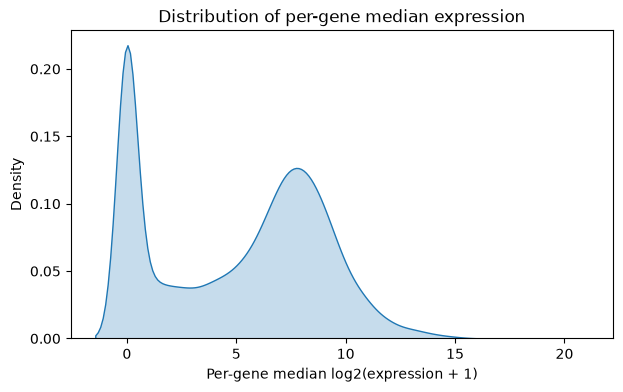

In [5]:
drop_gene = df.drop(columns=["Gene"])
drop_gene.index = df["Gene"]  # keep gene IDs as the index instead of losing them

drop_gene = drop_gene.T.groupby(meta["refinebio_title"]).sum().T
print(drop_gene.shape)
# should now print (32309, 32)

log_expr = np.log2(drop_gene + 1)
gene_medians = log_expr.median(axis=1)
gene_std = log_expr.std(axis=1)

print(gene_medians.describe())
print("Average per-gene std:", gene_std.mean())

plt.figure(figsize=(7, 4))
sns.kdeplot(gene_medians, fill=True)
plt.xlabel("Per-gene median log2(expression + 1)")
plt.ylabel("Density")
plt.title("Distribution of per-gene median expression")
plt.savefig("results/median_density.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP


log_expression = log_expr.T  # transpose to have samples as rows and genes as columns

pca = PCA(n_components=2)
tsne = TSNE(n_components=2, perplexity=8,random_state=42)
umap = UMAP(n_components=2, n_neighbors=10, min_dist=0.1, random_state=42)

c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
pca_result = pca.fit_transform(log_expression)
tsne_result = tsne.fit_transform(log_expression)
umap_result = umap.fit_transform(log_expression)

c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\marco\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1036

In [8]:
print("pca_result:", len(pca_result))
print("tsne_result:", len(tsne_result))
print("umap_result:", len(umap_result))

pca_result: 32
tsne_result: 32
umap_result: 32


In [9]:
with open("data/aggregated_metadata.json", "r") as f:
    metadata = json.load(f)

samples = metadata["samples"]
conditions = {}

for sample_id, info in samples.items():
    title = info["refinebio_title"]
    if title.startswith("Spaceflight"):
        conditions[sample_id] = "Spaceflight"
    elif title.startswith("Ground Control"):
        conditions[sample_id] = "Ground Control"

condition_series = meta.groupby(meta["refinebio_title"])["condition"].first()
condition_series = condition_series.loc[log_expr.columns]  # match the order used for PCA/tSNE/UMAP
print(len(condition_series))  # should now print 32

32


In [10]:
pca_df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "Condition": condition_series.values
})

tsne_df = pd.DataFrame({
    "tSNE1": tsne_result[:, 0],
    "tSNE2": tsne_result[:, 1],
    "Condition": condition_series.values
})

umap_df = pd.DataFrame({
    "UMAP1": umap_result[:, 0],
    "UMAP2": umap_result[:, 1],
    "Condition": condition_series.values
})

Text(0, 0.5, 'PC2 (17.4% variance)')

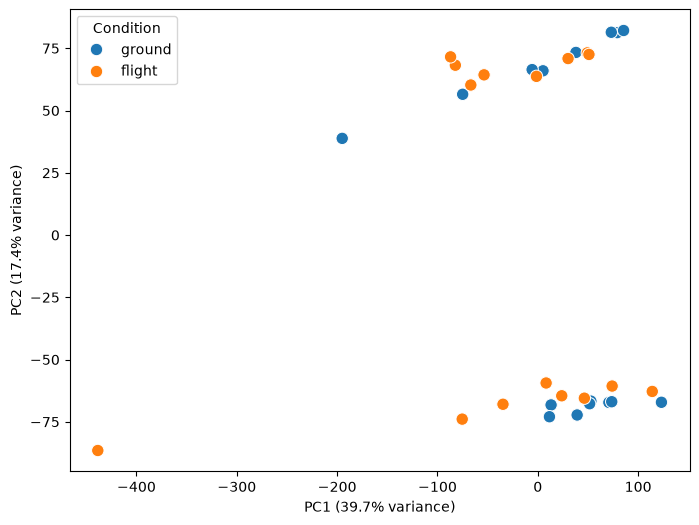

In [11]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Condition",
    s=80
)

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

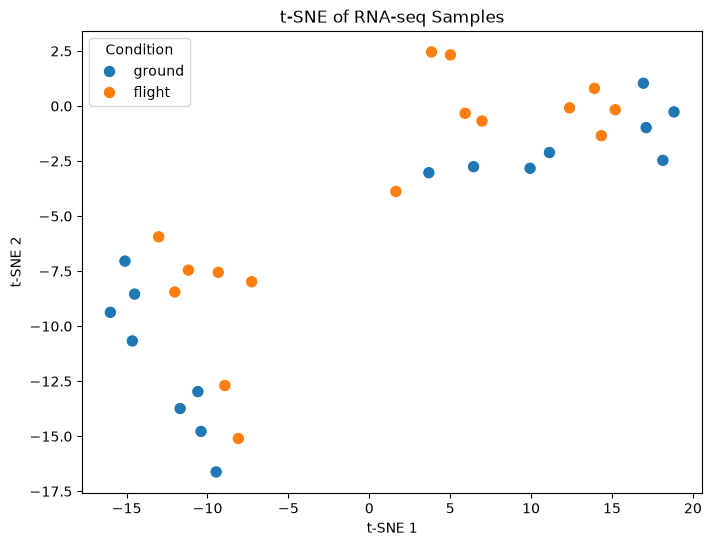

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tsne_df,
    x="tSNE1",
    y="tSNE2",
    hue="Condition",
    s=80
)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of RNA-seq Samples")

plt.show()

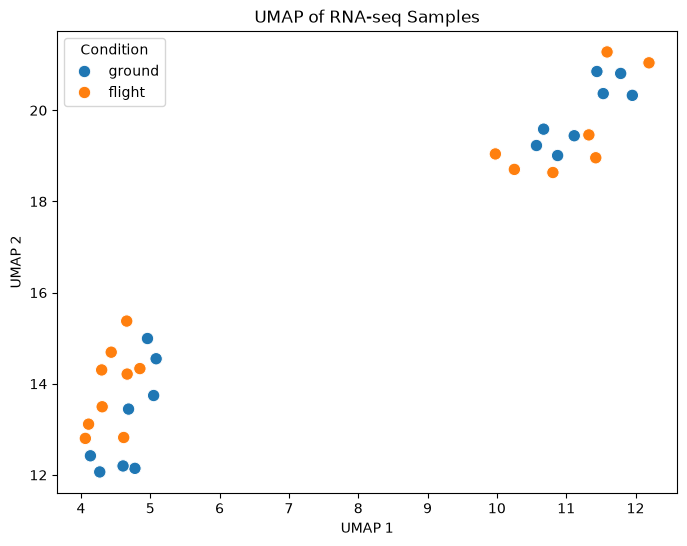

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="Condition",
    s=80
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP of RNA-seq Samples")

plt.show() 

In [14]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

In [15]:
sample_meta = meta.groupby("refinebio_title")[["condition", "age"]].first()

sample_meta = sample_meta.loc[log_expr.columns]

sample_meta["condition"].value_counts()

condition
ground    16
flight    16
Name: count, dtype: int64

In [16]:
flight = sample_meta.index[sample_meta["condition"] == "flight"]
ground = sample_meta.index[sample_meta["condition"] == "ground"]

In [17]:
flight_mean = log_expr[flight].mean(axis=1)
ground_mean = log_expr[ground].mean(axis=1)

effect = flight_mean - ground_mean

In [18]:
p_values = []

for gene in log_expr.index:
    test = ttest_ind(
        log_expr.loc[gene, flight],
        log_expr.loc[gene, ground],
        equal_var=False
    )

    p_values.append(test.pvalue)

In [19]:
results = pd.DataFrame({
    "Gene": log_expr.index,
    "Flight_Mean": flight_mean.values,
    "Ground_Mean": ground_mean.values,
    "Effect": effect.values,
    "P_Value": p_values
})

In [20]:
results["P_Value"] = results["P_Value"].fillna(1.0)

results["Adjusted_P_Value"] = multipletests(
    results["P_Value"],
    method="fdr_bh"
)[1]

In [21]:
results = results.sort_values("Adjusted_P_Value")
results.head()

,Gene,Flight_Mean,Ground_Mean,Effect,P_Value,Adjusted_P_Value
22410,AT4G18422,4.017964,6.191618,-2.173654,3.077363e-08,0.000994
28189,AT5G26070,4.125531,6.355828,-2.230297,2.547375e-07,0.004115
1322,AT1G07460,0.859820,3.241313,-2.381493,6.287299e-07,0.006771
27777,AT5G22300,4.319247,0.703215,3.616031,1.570084e-06,0.008455
6445,AT1G62190,2.939763,0.583983,2.355780,1.459032e-06,0.008455


In [22]:
results["Significant"] = results["Adjusted_P_Value"] < 0.05

results["Significant"].value_counts()

Significant
False    32257
True        52
Name: count, dtype: int64

In [23]:
results["-log10_p"] = -np.log10(results["Adjusted_P_Value"].clip(lower=1e-300))

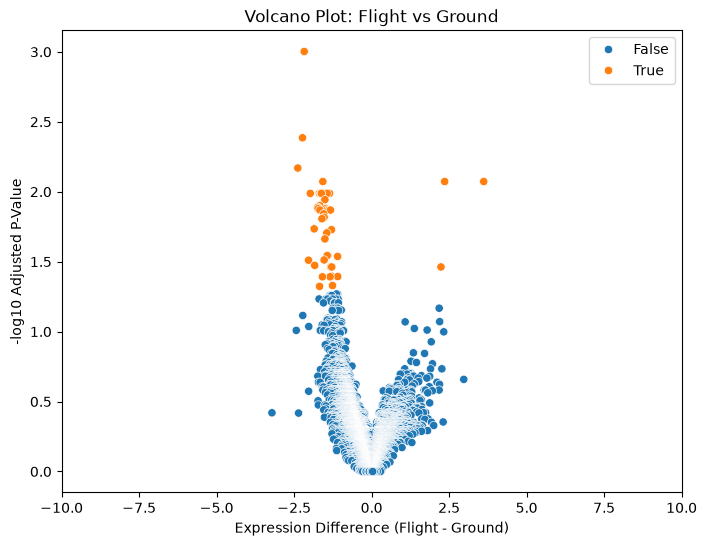

In [24]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=results,
    x="Effect",
    y="-log10_p",
    hue="Significant"
)

plt.xlabel("Expression Difference (Flight - Ground)")
plt.ylabel("-log10 Adjusted P-Value")
plt.title("Volcano Plot: Flight vs Ground")
plt.xlim(-10, 10)
plt.legend()

plt.show()

In [25]:
top50 = results.head(50)

top50

,Gene,Flight_Mean,Ground_Mean,Effect,P_Value,Adjusted_P_Value,Significant,-log10_p
22410,AT4G18422,4.017964,6.191618,-2.173654,3.077363e-08,0.000994,True,3.002498
28189,AT5G26070,4.125531,6.355828,-2.230297,2.547375e-07,0.004115,True,2.385614
1322,AT1G07460,0.859820,3.241313,-2.381493,6.287299e-07,0.006771,True,2.169334
27777,AT5G22300,4.319247,0.703215,3.616031,1.570084e-06,0.008455,True,2.072905
6445,AT1G62190,2.939763,0.583983,2.355780,1.459032e-06,0.008455,True,2.072905
22056,AT4G15480,6.064909,7.638009,-1.573100,1.423306e-06,0.008455,True,2.072905
29253,AT5G42180,8.968306,10.460555,-1.492250,6.125868e-06,0.010276,True,1.988192
20597,AT4G04840,8.151953,9.573474,-1.421520,2.439169e-06,0.010276,True,1.988192
8425,AT1G80340,6.150819,7.833425,-1.682607,6.360836e-06,0.010276,True,1.988192
4248,AT1G30750,8.913323,10.545563,-1.632240,3.920292e-06,0.010276,True,1.988192


In [26]:
results.to_csv(
    "results/differential_expression_all.csv",
    index=False
)

top50.to_csv(
    "results/differential_expression_top50.csv",
    index=False
)

In [27]:
sig_genes = results[
    results["Adjusted_P_Value"] < 0.05
]["Gene"]

In [28]:
heatmap_data = log_expr.loc[sig_genes]

In [29]:
group_colors = sample_meta["condition"].map({
    "flight": "red",
    "ground": "blue"
})

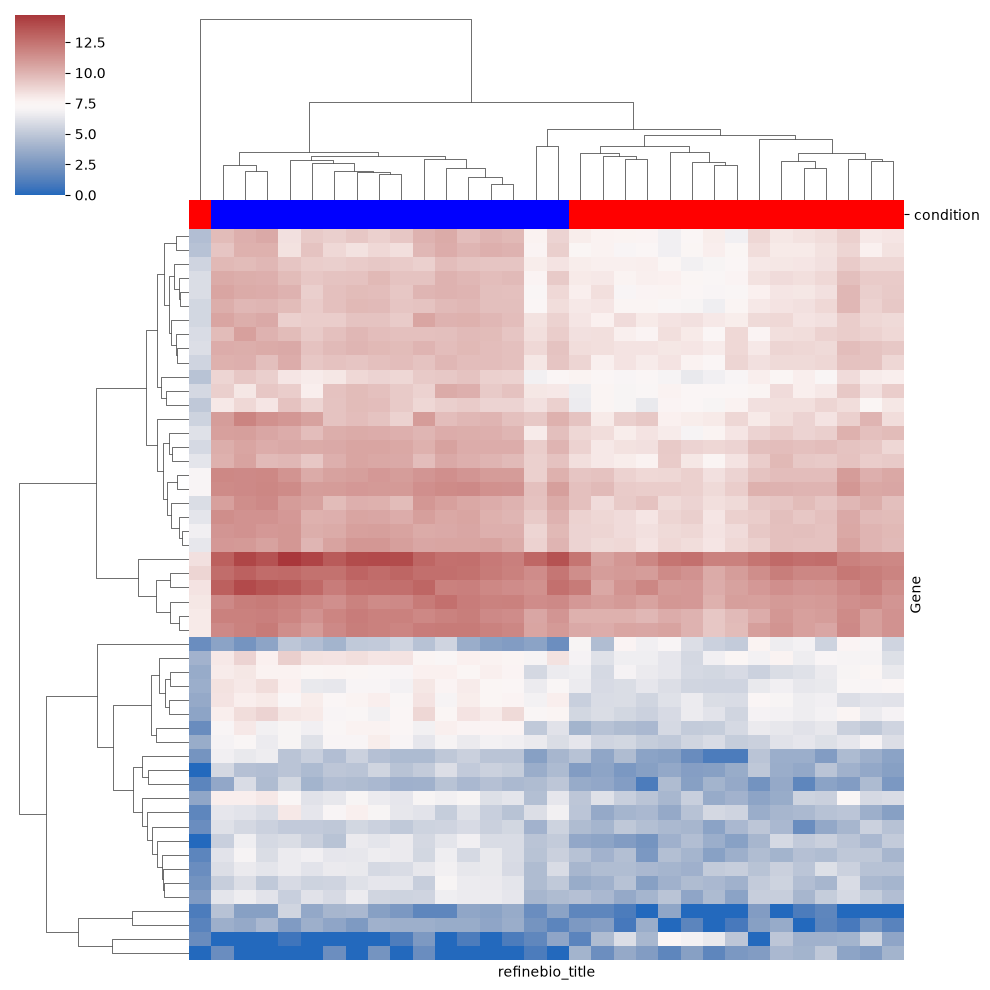

In [30]:
sns.clustermap(
    heatmap_data,
    col_colors=group_colors,
    cmap="vlag",
    xticklabels=False,
    yticklabels=False
)

plt.show()

In [31]:
import mygene

mg = mygene.MyGeneInfo()

In [32]:
genes = results["Gene"].tolist()

annotations = mg.querymany(
    genes,
    scopes="symbol",
    fields="go.BP",
    species=3702
)

11030 input query terms found no hit:	['AT5G22300', 'AT4G15480', 'AT5G42180', 'AT4G04840', 'AT1G80340', 'AT5G54470', 'AT3G21560', 'AT2G323


In [33]:
go_rows = []

for item in annotations:
    gene = item["query"]

    if "go" in item and "BP" in item["go"]:
        terms = item["go"]["BP"]

        if isinstance(terms, dict):
            terms = [terms]

        for term in terms:
            go_rows.append([
                gene,
                term["id"],
                term["term"]
            ])

In [34]:
go = pd.DataFrame(
    go_rows,
    columns=["Gene", "GO_ID", "GO_term"]
)

go = go.drop_duplicates()

go = go[
    go["GO_ID"] != "GO:0008150"
]

go.head()

,Gene,GO_ID,GO_term
1,AT1G62190,GO:0006631,fatty acid metabolic process
2,AT1G62190,GO:0006636,unsaturated fatty acid biosynthetic process
3,AT5G54790,GO:0009825,multidimensional cell growth
5,AT5G54790,GO:0010089,xylem development
6,AT3G17130,GO:0009827,plant-type cell wall modification


In [35]:
go.to_csv(
    "results/arabidopsis_go_bp_annotations.csv",
    index=False
)

In [36]:
go_data = go.merge(
    results[["Gene", "Effect"]],
    on="Gene"
)

In [37]:
from scipy.stats import mannwhitneyu

enrichment_results = []

for go_id, group in go_data.groupby("GO_ID"):
    inside = group["Effect"]

    outside = results[
        ~results["Gene"].isin(group["Gene"])
    ]["Effect"]

    if len(inside) >= 5:
        p = mannwhitneyu(
            inside,
            outside
        ).pvalue

        enrichment_results.append([
            go_id,
            group["GO_term"].iloc[0],
            len(inside),
            p
        ])

In [38]:
enrichment = pd.DataFrame(
    enrichment_results,
    columns=[
        "GO_ID",
        "GO_term",
        "Gene_Count",
        "P_Value"
    ]
)

In [39]:
enrichment["Adjusted_P_Value"] = multipletests(
    enrichment["P_Value"],
    method="fdr_bh"
)[1]

enrichment = enrichment.sort_values(
    "Adjusted_P_Value"
)

enrichment.head(20)

,GO_ID,GO_term,Gene_Count,P_Value,Adjusted_P_Value
200,GO:0009567,double fertilization forming a zygote and endo...,47,1.528972e-08,0.000010
646,GO:2000008,regulation of protein localization to cell sur...,43,1.212967e-07,0.000040
586,GO:0080155,regulation of double fertilization forming a z...,46,3.157778e-07,0.000069
545,GO:0055085,transmembrane transport,280,5.374726e-06,0.000887
447,GO:0042744,hydrogen peroxide catabolic process,66,1.334231e-05,0.001761
150,GO:0006979,response to oxidative stress,140,4.996231e-05,0.002771
580,GO:0080027,response to herbivore,12,5.038482e-05,0.002771
605,GO:0098869,cellular oxidant detoxification,77,2.981395e-05,0.002771
355,GO:0016567,protein ubiquitination,311,3.275736e-05,0.002771
195,GO:0009451,RNA modification,178,3.624848e-05,0.002771


In [40]:
enrichment.to_csv(
    "results/wilcoxon_GO_BP_enrichment.csv",
    index=False
)

In [41]:
print("Genes tested:", results["Gene"].nunique())
print("Genes with GO annotations:", go["Gene"].nunique())

Genes tested: 32309
Genes with GO annotations: 7882


In [42]:
wilcoxon = pd.read_csv("results/wilcoxon_GO_BP_enrichment.csv")
cluster = pd.read_csv("results/clusterProfiler_results.csv")
gprofiler = pd.read_csv("results/enrichment_gprofiler_GOBP.csv")

In [43]:
wilcoxon = wilcoxon.rename(columns={
    "P_Value": "Wilcoxon_P",
    "Adjusted_P_Value": "Wilcoxon_Adj"
})

cluster = cluster.rename(columns={
    "ID": "GO_ID",
    "Description": "Cluster_Term",
    "pvalue": "Cluster_P",
    "p.adjust": "Cluster_Adj",
    "qvalue": "Cluster_Q"
})

gprofiler = gprofiler.rename(columns={
    "native": "GO_ID",
    "name": "GProfiler_Term",
    "p_value": "GProfiler_P",
    "significant": "GProfiler_Significant"
})

In [44]:
combined = wilcoxon.merge(
    cluster,
    on="GO_ID",
    how="outer"
)

combined = combined.merge(
    gprofiler,
    on="GO_ID",
    how="outer"
)

In [45]:
combined["GO_term"] = combined["GO_term"].fillna(
    combined["Cluster_Term"]
)

combined["GO_term"] = combined["GO_term"].fillna(
    combined["GProfiler_Term"]
)

In [46]:
combined["Methods_Included"] = (
    combined["Wilcoxon_P"].notna().astype(int)
    + combined["Cluster_P"].notna().astype(int)
    + combined["GProfiler_P"].notna().astype(int)
)

In [48]:
combined["Methods_Significant"] = (
    (combined["Wilcoxon_Adj"] < 0.05).fillna(False).astype(int)
    + (combined["Cluster_Adj"] < 0.05).fillna(False).astype(int)
    + combined["GProfiler_Significant"].fillna(False).astype(int)
)

C:\Users\marco\AppData\Local\Temp\ipykernel_26204\1592190246.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  + combined["GProfiler_Significant"].fillna(False).astype(int)


In [49]:
combined = combined.sort_values(
    ["Methods_Significant", "Methods_Included"],
    ascending=False
)

combined.head(20)

,GO_ID,GO_term,Gene_Count,Wilcoxon_P,Wilcoxon_Adj,Cluster_Term,setSize,enrichmentScore,NES,Cluster_P,...,intersection_size,effective_domain_size,precision,recall,query,parents,intersections,evidences,Methods_Included,Methods_Significant
191,GO:0007623,circadian rhythm,18.0,0.000293,0.012092,circadian rhythm,158.0,-0.439908,-1.472747,2.083998e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
215,GO:0009411,response to UV,NaN,NaN,NaN,response to UV,133.0,-0.419156,-1.381164,3.401018e-03,...,4.0,32365.0,0.076923,0.034483,query_1,['GO:0009416'],"['AT4G15480', 'AT4G14690', 'AT3G22840', 'AT3G2...","[['IGI', 'IEP'], ['IEP'], ['IEP'], ['IEP']]",2,2
245,GO:0009664,plant-type cell wall organization,20.0,0.000396,0.015089,plant-type cell wall organization,230.0,-0.405704,-1.385202,3.081368e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
249,GO:0009698,phenylpropanoid metabolic process,NaN,NaN,NaN,phenylpropanoid metabolic process,145.0,-0.512314,-1.706801,9.485013e-08,...,8.0,32365.0,0.153846,0.048780,query_1,['GO:0019748'],"['AT5G66390', 'AT3G21560', 'AT3G55230', 'AT3G2...","[['IMP'], ['IMP'], ['IEA'], ['IEA'], ['IEA'], ...",2,2
250,GO:0009699,phenylpropanoid biosynthetic process,NaN,NaN,NaN,phenylpropanoid biosynthetic process,109.0,-0.577742,-1.890091,7.370089e-10,...,6.0,32365.0,0.115385,0.050847,query_1,"['GO:0009698', 'GO:0044550']","['AT5G66390', 'AT3G55230', 'AT3G24020', 'AT2G3...","[['IMP'], ['IEA'], ['IEA'], ['IEA'], ['IEA'], ...",2,2
279,GO:0009809,lignin biosynthetic process,7.0,0.000045,0.002771,lignin biosynthetic process,54.0,-0.529867,-1.625303,9.122892e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
321,GO:0010089,xylem development,10.0,0.000530,0.018414,xylem development,45.0,-0.519003,-1.573848,3.181690e-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
411,GO:0016567,protein ubiquitination,311.0,0.000033,0.002771,protein ubiquitination,363.0,-0.415048,-1.434089,9.136896e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2
429,GO:0019748,secondary metabolic process,NaN,NaN,NaN,secondary metabolic process,242.0,-0.433451,-1.476872,7.573403e-06,...,9.0,32365.0,0.173077,0.033582,query_1,['GO:0008152'],"['AT5G66390', 'AT3G21560', 'AT3G55230', 'AT3G2...","[['IMP'], ['IMP'], ['IEA'], ['IEA'], ['IEA'], ...",2,2
490,GO:0034330,cell junction organization,NaN,NaN,NaN,cell junction organization,14.0,-0.761557,-1.887138,1.483258e-04,...,3.0,32365.0,0.057692,0.272727,query_1,['GO:0016043'],"['AT2G36100', 'AT2G27370', 'AT3G11550']","[['IDA'], ['IDA'], ['IDA']]",2,2


In [50]:
combined.to_csv(
    "results/combined_enrichment_results.csv",
    index=False
)

In [57]:
top_terms = combined[
    combined["Methods_Significant"] == 2
]

In [58]:
top10 = top_terms.head(10)

top10[[
    "GO_ID",
    "GO_term",
    "Methods_Included",
    "Methods_Significant"
]]

,GO_ID,GO_term,Methods_Included,Methods_Significant
191,GO:0007623,circadian rhythm,2,2
215,GO:0009411,response to UV,2,2
245,GO:0009664,plant-type cell wall organization,2,2
249,GO:0009698,phenylpropanoid metabolic process,2,2
250,GO:0009699,phenylpropanoid biosynthetic process,2,2
279,GO:0009809,lignin biosynthetic process,2,2
321,GO:0010089,xylem development,2,2
411,GO:0016567,protein ubiquitination,2,2
429,GO:0019748,secondary metabolic process,2,2
490,GO:0034330,cell junction organization,2,2


In [59]:
top10.to_csv(
    "results/top10_combined_enrichment.csv",
    index=False
)